### Langchain version V1

In [9]:
import os 
from dotenv import load_dotenv
from langchain_groq import ChatGroq
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [21]:
llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)

In [22]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """ Get the weather for the city """
    return f"The weather in {city} is windy"

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are an helpful assistant",
)

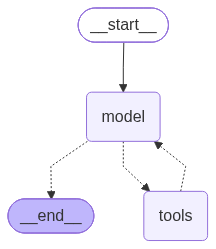

In [23]:
agent

In [25]:
### Running the agent

responses = agent.invoke({"messages":[{"role":"user", "content":"what is the weather in hyderabad now?"}]}) ## role is user because the message is from user, we will explore about messages more down below

In [26]:
responses["messages"][-1].content

'It’s currently windy in Hyderabad! If you need more details—like temperature, humidity, or a forecast—just let me know.'

In [27]:
import langchain
langchain.__version__

'1.3.14'

### Streaming and batch

Streaming in LangChain refers to the ability to receive output incrementally—token by token or event by event—rather than waiting for an entire pipeline or agent execution to finish.

calling stream() returns a iterator that yields output chunks as they are produced and you can use a loop to process each chunk in real time

In [ ]:
for chunk,metadata in agent.stream(
    {"messages": [("user", "Write 200 words on The Witcher 3 game.")]},
    stream_mode="messages" # .stream() returns state dictionaries like {'agent': {'messages': [...]}}. Setting stream_mode="messages" forces it to yield individual streamable message tokens (chunk.content)
):
    print(chunk.content, end="", flush=True)

**The Witcher 3: Wild Hunt** is a sprawling, narrative‑driven action RPG that redefined the genre upon its 2015 release. Developed by CD Projekt Red, the game places players in the boots of Geralt of Rivia, a monster hunter navigating a war‑torn, morally ambiguous world. Its open‑world design is a masterclass in environmental storytelling: from the mist‑shrouded swamps of Velen to the snow‑capped peaks of the Skellige Isles, each region feels alive, populated by dynamic NPCs, weather systems, and emergent quests that ripple across the map.

Gameplay blends visceral combat with deep RPG mechanics. Geralt’s arsenal—swords, signs, alchemy, and a vast array of monster‑specific tactics—offers tactical depth, while the skill tree and gear customization allow for a wide range of playstyles. The game’s narrative is a tapestry of branching choices, where even seemingly minor decisions can alter the fates of characters and entire factions, culminating in multiple endings that reflect the player’

## Batch

batching is a collection of independent requests made to a model can significantly improve the performance, reduce costs as the processing can be done in parallel

In [37]:
# Pass a list of input dictionaries
responses = agent.batch([
    {"messages": [("user", "what is the weather in uganda?")]}, 
    {"messages": [("user", "what is game development in short?")]}
])

# Process the outputs
for i, response in enumerate(responses):
    # Extract the last message from each batch item's output state
    last_message = response["messages"][-1].content
    print(f"--- Response {i+1} ---")
    print(last_message)
    print()

--- Response 1 ---
I’m happy to help! Uganda is a country, so the weather can vary across regions. Could you let me know which city or area you’re interested in (e.g., Kampala, Entebbe, Jinja, etc.)? If you’d like a general overview, I can provide the current conditions for the capital, Kampala.

--- Response 2 ---
Game development is the process of creating a video game, from initial concept and design through programming, art, sound, testing, and release. It combines storytelling, mechanics, technology, and teamwork to build interactive experiences that run on computers, consoles, or mobile devices.



In [38]:
# responses = agent.batch([
#     {"messages": [("user", "what is the weather in uganda?")]}, 
#     {"messages": [("user", "what is game development in short?")]}
# ],
# config={
#     'max_concurrency':5, #limit to 5 parallel calls
# })

## Tools in Langchain

Models can request to call tools that perform tasks suchs as fetching data from database, searching from web or running code

In [46]:
from langchain.tools import tool # can be used as decorative before defining a function for tool

@tool 
def goat_of_football(name:str)->str:
    """Run this function for who is the GOAT of football?"""
    return f"The goat of football is Cristaino Ronaldo not {name}"

In [47]:
agent = create_agent(
    model=llm,
    tools=[get_weather, goat_of_football],
    system_prompt="You are an helpful assistant",
)

In [61]:
responses = agent.invoke({"messages":[{"role":"user", "content":"Is messi goat of football?"}]})

In [62]:
responses

{'messages': [HumanMessage(content='Is messi goat of football?', additional_kwargs={}, response_metadata={}, id='d1c8d8c8-2c82-43cf-83f9-4f87c15d6100'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Is Messi goat of football?" They want an answer. We can respond with a short answer. The user didn\'t ask for weather or goat_of_football function. The goat_of_football function expects a name. We could call goat_of_football with name "Messi" to get an answer. But the function is "Run this function for who is the GOAT of football?" It might return something. But the user just asks a question. We can answer directly. But maybe we should use the function to get a more authoritative answer. The function likely returns something like "Lionel Messi is considered by many as the GOAT." But we don\'t know. We can call goat_of_football with name "Messi". Let\'s do that.', 'tool_calls': [{'id': 'fc_ff536c82-82fc-4f05-9f10-64278f8a5260', 'function': {'arguments': '{"

In [68]:
for message in responses["messages"]:
    if hasattr(message, "tool_calls") and message.tool_calls:
        for tool_call in message.tool_calls:
            result = goat_of_football.invoke(tool_call)
            print(result)
            print(f"Tool Used: {tool_call['name']}")
            print(f"Args Used: {tool_call['args']}")

content='The goat of football is Cristaino Ronaldo not Messi' name='goat_of_football' tool_call_id='fc_ff536c82-82fc-4f05-9f10-64278f8a5260'
Tool Used: goat_of_football
Args Used: {'name': 'Messi'}


## Messages

Messages are the fundamental data structures used to represent conversational interactions with Chat Models. They represent the input and output of models, carruing both the content and metadata needed to represent the state of a conversation when interacting with an LLM, Messages are objects that contain:

* Role - Identifies the message type (eg. system, user)
* content - Represents the actual content of the message (like text, images, audio, documents etc) 
* metadata - Optional fields such as response information, message IDs and token usage

In [70]:
llm.invoke("what is LLM in short?")

AIMessage(content='**LLM** = **Large Language Model** – a type of AI that learns from vast amounts of text to understand, generate, and manipulate human language.', additional_kwargs={'reasoning_content': 'The user asks: "what is LLM in short?" They likely want a short definition of LLM. LLM stands for "Large Language Model" or "Master of Laws" depending on context. In AI context, it\'s "Large Language Model". So answer: LLM = Large Language Model, a type of AI that processes language. Provide short explanation.'}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 78, 'total_tokens': 193, 'completion_time': 0.137331033, 'completion_tokens_details': {'reasoning_tokens': 74}, 'prompt_time': 0.003650799, 'prompt_tokens_details': None, 'queue_time': 0.318669987, 'total_time': 0.140981832}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, i

## Text Prompts - 

Text prompts are stings which is straightforward generation tasks where you don't need to retain conversation history

In [71]:
# example - 
# llm.invoke("what is LLM in short?")

## Message prompts

You can aslo pass in the list of messages to the model by providing a list of message objects

Message types - 
* System Message - Tells the model how to behave and provide context for interactions 
* Human message - represents user input and interactions with the model
* AI message - responses generated by the model including text content, tool calls, and metadata
* Tool message - represents the output of the tools

In [73]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

messages = [
    SystemMessage("You are a football analyst expert"), # we can also add in a variable and replace here in the message types
    HumanMessage("Can you explain what is VAR in football?"),
]

response = llm.invoke(messages)
response.content

'**VAR** stands for **Video Assistant Referee**. It’s a technology‑based system introduced to help on‑field referees make more accurate decisions in key moments of a football match. Here’s a quick rundown of what VAR is, how it works, and why it matters:\n\n---\n\n## 1. The Purpose of VAR\n\n- **Reduce clear errors**: Mistakes in goals, penalties, red cards, and missed or wrong player identification can change the outcome of a game. VAR aims to catch those.\n- **Support the referee**: The on‑field referee remains the final decision‑maker; VAR is a support tool, not a replacement.\n- **Maintain fairness**: By reviewing critical incidents, VAR helps ensure that the rules are applied consistently.\n\n---\n\n## 2. How VAR Works\n\n### 2.1 The Setup\n\n- **Multiple camera angles**: Stadiums are equipped with 8–12 cameras covering the pitch from various angles (including high‑speed, slow‑motion, and 360° views).\n- **VAR team**: A group of 3–4 officials sits in a remote control room. They in

In [74]:
## Details information to the LLM through system message

system_msg = SystemMessage("""
You are SQL expert with expertise on SQL frameworks.
Always provide code examples and explain your reasoning.
Be consice and accurate in the explanations
""")

messages = [
    system_msg,
    HumanMessage("what are SQL frameworks?")
]

responses = llm.invoke(messages)
print(responses.content)

**SQL frameworks** are libraries or toolkits that help you work with relational databases in a more productive, consistent, and often database‑agnostic way.  
They usually provide one or more of the following:

| Category | Typical purpose | Example |
|----------|-----------------|---------|
| **ORM (Object‑Relational Mapping)** | Map database tables to language objects, generate SQL automatically, and provide a high‑level API. | `SQLAlchemy` (Python), `Django ORM` (Python), `Hibernate` (Java), `Entity Framework` (C#) |
| **Schema migration** | Track, version, and apply changes to the database schema over time. | `Alembic` (Python), `Flyway` (Java), `Liquibase` (Java), `Flyway` (Node.js) |
| **Query builder / DSL** | Build SQL queries programmatically, often with type safety. | `Knex.js` (Node.js), `jOOQ` (Java), `QueryDSL` (Java) |
| **Database abstraction / connection pooling** | Manage connections, pooling, and transaction handling. | `pg-promise` (Node.js), `HikariCP` (Java), `psyc

In [75]:
## Human message with metadata

human_msg = HumanMessage(
    content="heys",
    name="ashish", # optional - identify different users
    id="msg_123" # optional - unique identifier for tracing
)

human_msg

HumanMessage(content='heys', additional_kwargs={}, response_metadata={}, name='ashish', id='msg_123')

In [76]:
responses.usage_metadata

{'input_tokens': 107,
 'output_tokens': 1093,
 'total_tokens': 1200,
 'output_token_details': {'reasoning': 59}}

In [77]:
# Tool Message

ai_message = AIMessage(
    content=[],
    tool_calls = [{
        "name":"get_weather",
        "args":{"locations":"Mumbai"},
        "id": "call_123"
    }]
)

weather_result = "windy, 32 degrees celcius"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id = "call_123" # must the call ID in the above AI message
)

messages = [
    HumanMessage("what is the weather in mumbai?"),
    ai_message,
    tool_message
]

response = llm.invoke(messages)
print(response.content)

The weather in Mumbai is **windy, 32 °C**.


In [78]:
response

AIMessage(content='The weather in Mumbai is **windy, 32\u202f°C**.', additional_kwargs={'reasoning_content': 'We have a function call to get_weather. The function returned "windy, 32 degrees celcius". The user asked "what is the weather in mumbai?" The assistant should respond with that. The function call was executed and returned. So we should respond with the weather.'}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 112, 'total_tokens': 194, 'completion_time': 0.093319528, 'completion_tokens_details': {'reasoning_tokens': 58}, 'prompt_time': 0.00543632, 'prompt_tokens_details': None, 'queue_time': 0.317458487, 'total_time': 0.098755848}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07d19-dc51-74c1-811b-edbbd55a00b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 112, 'output_tokens': 82

## Structured output

Models can be requested to provide their response in a format matching in a given schema. This is useful for ensuing the output can be easily parsed and used in subsequent processing. Langchain supports mulitple schema types and methods for enforcing structured output


### 1 - Pydantic

Pyantic models provide the richest feature set with field validation, descriptions and nested stuctures

In [ ]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title:str=Field(description="The title of the movie") ## LLM should put title of the movie which should be string in this field (field validation)
    year:int=Field(description="The year of the movie released date")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The rating of the movie out of 5")

In [80]:
model_with_output_stucture = llm.with_structured_output(Movie)

model_with_output_stucture

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.3.14'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026438AACDD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026438AAEC90>, model_name='openai/gpt-oss-20b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'des

In [86]:
model_with_output_stucture.invoke("Provide details about the movie rocky series")

Movie(title='Rocky', year=1976, director='John G. Avildsen', rating=4.5)

In [ ]:
## Message output alongside parsed structure


class Movie(BaseModel):
    title:str=Field(description="The title of the movie") ## LLM should put title of the movie which should be string in this field (field validation)
    year:int=Field(description="The year of the movie released date")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The rating of the movie out of 5")
    customField:str=Field(...,description="In progress do not fill this field and do not marked this as N/A, just let it be empty") ## Marked as required with ...

model_with_output_stucture = llm.with_structured_output(Movie, include_raw=True) ## include_raw=True - includes raw AIMessage generated alongside the structured output

model_with_output_stucture.invoke("Provide details about the movie rocky series")

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': "User wants details about the Rocky series. Likely want a summary of each film, release year, director, rating. We can use the function to provide details for each movie. The function signature: Movie takes customField, director, rating, title, year. We can call function for each movie. Provide details. Probably list each film: Rocky (1976), Rocky II (1979), Rocky III (1982), Rocky IV (1985), Rocky V (1990), Rocky Balboa (2006), Creed (2015), Creed II (2018). Provide director, rating (subjective). Use customField maybe empty. We'll call function for each.", 'tool_calls': [{'id': 'fc_ed2bc8ca-6092-441d-a033-a0f3971c5d6f', 'function': {'arguments': '{"customField":"","director":"John G. Avildsen","rating":4.5,"title":"Rocky","year":1976}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 188, 'prompt_tokens': 188, 'total_tokens': 376, 'completion_time': 0.243892497, 'comp

In [92]:
## Nested structures

class footballer(BaseModel):
    name:str
    footballer_role: str

class XIFootballer(BaseModel):
    year:int
    players: list[footballer] = Field(description="Put the player names in this field") ## Nested structures


model_with_output_stucture = llm.with_structured_output(XIFootballer)

model_with_output_stucture.invoke("Best 11 football players in the history of football")

XIFootballer(year=2023, players=[footballer(name='Lev Yashin', footballer_role='Goalkeeper'), footballer(name='Cafu', footballer_role='Right Back'), footballer(name='Franz Beckenbauer', footballer_role='Center Back'), footballer(name='Paolo Maldini', footballer_role='Center Back'), footballer(name='Roberto Carlos', footballer_role='Left Back'), footballer(name='Xavi', footballer_role='Central Midfield'), footballer(name='Zinedine Zidane', footballer_role='Central Midfield'), footballer(name='Lothar Matthäus', footballer_role='Central Midfield'), footballer(name='Lionel Messi', footballer_role='Right Forward'), footballer(name='Pelé', footballer_role='Center Forward'), footballer(name='Diego Maradona', footballer_role='Left Forward')])

### TypedDict

TypedDict provides a simpler alternative using python build-in typing, ideal when you do not need runtime validations

In [ ]:
from typing_extensions import TypedDict, Annotated

class MovieDict(TypedDict):
    title:Annotated[str,...,"The title of the movie"]
    year:Annotated[int,...,"The year of the movie released date"]
    director:Annotated[str,..., "The director of the movie"]
    rating:Annotated[float, ...,"The rating of the movie out of 5"] ## ... optional metadata and ignored not relevant BTW

model_with_output_stucture = llm.with_structured_output(MovieDict)

model_with_output_stucture

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.3.14'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026438AACDD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026438AAEC90>, model_name='openai/gpt-oss-20b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'MovieDict', 'description': "dict() -> new empty dictionary\ndict(mappin

In [94]:
model_with_output_stucture.invoke("Provide details about the movie rocky series")

{'director': 'John G. Avildsen', 'rating': 4.5, 'title': 'Rocky', 'year': 1976}

In [95]:
## we can also have nested structures with typedDict

## model profile

llm.profile

{'name': 'GPT OSS 20B',
 'release_date': '2025-08-05',
 'last_updated': '2026-05-27',
 'open_weights': True,
 'max_input_tokens': 131072,
 'max_output_tokens': 65536,
 'text_inputs': True,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'text_outputs': True,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True,
 'structured_output': True,
 'attachment': False,
 'temperature': True}

### Dataclasses

A data class is a class typically containing mainly data, although there aren't really any restrictions. You can create it using the @dataclass decorator

In [96]:
# we can aslo put the output format while creating the agent using create_agent

# agent = create_agent(
#     model=llm,
#     tools=[get_weather],
#     system_prompt="You are an helpful assistant",
#     response_format=<class we have created for output format>
# )


In [97]:
from dataclasses import dataclass

@dataclass
class Movie:
    """Movie information for a particular movie"""
    name: str # name of the movie
    director: str # director of the movie
    genre: str # genre of the movie


agent = create_agent(
    model=llm,
    response_format=Movie
)

result = agent.invoke({"messages":"Tell me about the movie the martian"})

result["structured_response"]

Movie(name='The Martian', director='Ridley Scott', genre='Science Fiction')

## Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

* Tracking agent behavior with logging, analytics and debugging
* transforming prompts, tool selection and output formatting
* adding retries, fallbacks and early termination logic
* applying rate limits, guardrails, and PII detection.

In [98]:
## built in middleware Summarization, human in the feedback, model call limit see in langchain middleware documentation...

# SummarizationMiddleware	Automatically summarize conversation history when approaching token limits

# HumanInTheLoopMiddleware	Pause execution for human approval of tool calls

# ModelCallLimitMiddleware	Limit the number of model calls to prevent excessive costs

# ToolCallLimitMiddleware	Control tool execution by limiting call counts

# ModelFallbackMiddleware	Automatically fallback to alternative models when primary fails

# PIIMiddleware	Detect and handle Personally Identifiable Information

# TodoListMiddleware	Equip agents with task planning and tracking capabilities

# LLMToolSelectorMiddleware	Use an LLM to select relevant tools before calling main model

# ToolRetryMiddleware	Automatically retry failed tool calls with exponential backoff

# LLMToolEmulator	Emulate tool execution using LLM for testing purposes

# ContextEditingMiddleware	Manage conversation context by trimming or clearing tool uses

# ShellToolMiddleware	Expose a persistent shell session to agents for command execution

# FilesystemFileSearchMiddleware	Provide Glob and Grep search tools over filesystem files

# AgentMiddleware	Base middleware class for creating custom middleware

### Summarization middleware

In LangChain and LangGraph ecosystem, Summarization Middleware (often implemented via message-trimming utilities or custom summarization graph nodes) is a pattern used to manage long-running conversations that exceed an LLM's context window limit.

Instead of dropping old conversation history or running out of tokens, the summarization middleware automatically compresses historical messages into a running textual summary while keeping recent messages intact.

- Context Window Optimization: Prevents ContextWindowExceededError on long-running multi-turn agent sessions.

- Cost Reduction: Reduces token consumption per LLM call by compressing dozens of old messages into a single concise summary message.

- Information Retention: Retains critical context from earlier in the interaction (such as user preferences or task constraints) that would otherwise be lost if messages were simply truncated or popped off.

A Checkpoint is a saved snapshot of your agent's internal state at a specific point in time.

Checkpointing is what gives agents memory, durability, and time-travel capabilities. Without a checkpointer, an agent evaluates a request in isolation and forgets everything as soon as execution completes.

Core Uses of Checkpoints
Multi-turn Memory: Automatically saves conversation state across user interactions using a thread_id.

Human-in-the-Loop: Pauses agent execution before dangerous or critical steps (like running a code script or executing a financial transaction), allowing humans to inspect or approve the state before resuming.

Fault Tolerance & Recovery: If a tool call or API crashes midway, the agent can resume execution from the last successful checkpoint instead of starting over.

State Rewinding ("Time Travel"): Allows developers or users to rewind to a previous step, modify inputs or state, and fork execution down a new path.

In [99]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver # It stores checkpoints in-memory (RAM), making it ideal for local testing, development, and debugging.

## Message based summarization

agent = create_agent(
    model=llm,
    checkpointer=InMemorySaver(),
    middleware=[ # provide the list of middlewares
        SummarizationMiddleware(
            model=llm, # what LLM model we are using for summarization,
            trigger=("messages", 10), # summarize the last 10 messages
            keep=("messages", 4) # keep the recent 4 messages as is
        )
    ]
)

In [100]:
### Run with thread ID

config = {"configurable": {"thread_id":"test-1"}}

LangGraph agents are stateless by default. When you run agent.invoke(), the agent has no memory of previous runs unless a checkpointer is attached and a thread_id is provided in the configuration.

By passing a thread_id:

Multi-Turn Conversations: The checkpointer loads all past messages associated with that specific ID before running the agent, and saves the updated state after execution finishes.

User Isolation: Multiple users can talk to the same agent simultaneously. Each user gets their own thread_id, ensuring their conversation histories and tool state remain isolated and secure.

Branching & Time-Travel: You can inspect or rewind execution steps for a given thread without affecting other active conversations.

In [102]:
questions = [
    "what is 1 + 1", 
    "what is 2 * 2",
    "what is 4/1",
    "what is 4+3",
    "what is 6*8",
    "what is 5*6"
]

for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]}, config=config)
    print(f"Messages: {response}")
    print(f"Messages length: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='what is 1 + 1', additional_kwargs={}, response_metadata={}, id='bacd7c5d-a343-4c6a-8882-a8370cee4c78'), AIMessage(content='1\u202f+\u202f1\u202f=\u202f2', additional_kwargs={'reasoning_content': 'The user asks: "what is 1 + 1". It\'s a simple arithmetic question. The answer is 2. There\'s no special context. Just answer.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 78, 'total_tokens': 130, 'completion_time': 0.052907462, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.003686363, 'prompt_tokens_details': None, 'queue_time': 0.047866086, 'total_time': 0.056593825}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07daa-24df-7ed0-b730-2f21abb434e6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 52, 'to

In [108]:
# Summarization based on token size

agent = create_agent(
    model=llm,
    checkpointer=InMemorySaver(),
    middleware=[ # provide the list of middlewares
        SummarizationMiddleware(
            model=llm, # what LLM model we are using for summarization,
            trigger=("tokens", 30), # when the token hits 550
            keep=("tokens", 20) # keep the recent 200 token when it hits trigger as is
        )
    ]
)

config = {"configurable": {"thread_id":"test-1"}}

def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token

In [109]:
questions = [
    "what is 1 + 1", 
    "what is 2 * 2",
    "what is 4/1",
    "what is 4+3",
    "what is 6*8",
    "what is 5*6"
]

for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]}, config=config)
    tokens = count_token(response["messages"])
    print(f"The total tokens for {q} is {tokens} and length of message {len(response['messages'])}")
    print(f"Messages: {response}")
    

The total tokens for what is 1 + 1 is 5 and length of message 2
Messages: {'messages': [HumanMessage(content='what is 1 + 1', additional_kwargs={}, response_metadata={}, id='1497c063-b7f8-4407-8ee0-bb266e1e3b05'), AIMessage(content='1\u202f+\u202f1\u202f=\u202f2', additional_kwargs={'reasoning_content': 'The user asks: "what is 1 + 1". It\'s a simple arithmetic question. The answer is 2. There\'s no special context. Just answer.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 78, 'total_tokens': 130, 'completion_time': 0.058637273, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.035759132, 'prompt_tokens_details': None, 'queue_time': 0.363232504, 'total_time': 0.094396405}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8e23cedc90', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07db4-e817-76c3-a965-77b320f8cc5a-0', tool_calls=[], invalid_tool_calls=

In [110]:
## summarisation based on fraction

# agent = create_agent(
#     model=llm,
#     checkpointer=InMemorySaver(),
#     middleware=[ # provide the list of middlewares
#         SummarizationMiddleware(
#             model=llm, # what LLM model we are using for summarization,
#             trigger=("fraction", 0.005), # when the fraction hits 0.05% of tokens which can be accomodiated by the model (model context) lets say 160k tokens
#             keep=("tokens", 0.002) # keep the recent 0.002% of the tokens
#         )
#     ]
# )

# def count_token(messages):
#     total_chars = sum(len(str(m.content)) for m in messages)
#     return total_chars // 4 # 4 chars = 1 token


# for q in questions:
#     response = agent.invoke({"messages":[HumanMessage(content=q)]}, config=config)
#     tokens = count_token(response["messages"])
#     fraction = tokens / 131072 # openai/gpt-oss-20b supported model context size limit
#     print(f"The total tokens for {q} is {tokens} and length of message {len(response['messages'])} and Fraction {fraction:.4%}")
#     print(f"Messages: {response}")

In [111]:
snapshot = agent.get_state(config)

# Print all saved message types in order
for msg in snapshot.values["messages"]:
    print(f"[{msg.__class__.__name__}]: {msg.content}")

[HumanMessage]: Here is a summary of the conversation to date:

## SESSION INTENT
Compute the result of the arithmetic expression 6 × 8.

## SUMMARY
The user has asked for the value of 6 × 8. No additional constraints or context were provided.

## ARTIFACTS
None.

## NEXT STEPS
Respond with the answer: 48.
[AIMessage]: 6 × 8 = 48
[HumanMessage]: what is 5*6
[AIMessage]: 5 × 6 = 30
